In [ ]:
# Se importan las librerias
import numpy as np
import pandas as pd
import matplotlib as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import openpyxl
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder


In [ ]:
# ============================================================
# CELDA 2 – Cargar el conjunto de datos
# ============================================================

df = pd.read_csv('/content/telecom_customer_churn.csv')

print(f"Se cargaron {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

Se cargaron 7043 filas y 38 columnas.


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
# ============================================================
# CELDA 3 – Crear variable objetivo Y (equivalente a PreApr)
# Solo se conservan clientes "Stayed" o "Churned"
# (los "Joined" se eliminan porque aún no tienen historial)
# ============================================================
df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()

# 1 = Churned (positivo), 0 = Stayed (negativo)
df['Churn'] = (df['Customer Status'] == 'Churned').astype(int)

print("Distribución del target:")
print(df['Churn'].value_counts())
print(f"\nTasa de churn: {df['Churn'].mean():.1%}")

Distribución del target:
Churn
0    4720
1    1869
Name: count, dtype: int64

Tasa de churn: 28.4%


In [ ]:
# ============================================================
# CELDA 4 – Definir X categórica y X numérica
# (misma lógica que Estado civil / Nivel estudios / Edad / etc.)
# ============================================================
X_categorical = df[[
    'Gender', 'Married', 'Offer', 'Phone Service',
    'Multiple Lines', 'Internet Service', 'Internet Type',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Contract',
    'Paperless Billing', 'Payment Method'
]]

X_numerical = df[[
    'Age', 'Number of Dependents', 'Number of Referrals',
    'Tenure in Months', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Monthly Charge',
    'Total Charges', 'Total Refunds',
    'Total Extra Data Charges', 'Total Long Distance Charges',
    'Total Revenue'
]]

y = df['Churn']

print("Variables categóricas:", X_categorical.shape[1])
print("Variables numéricas   :", X_numerical.shape[1])

Variables categóricas: 18
Variables numéricas   : 12


In [ ]:
# ============================================================
# CELDA 5 – Codificar variables categóricas (OrdinalEncoder)
# ============================================================
X_cat_encod = X_categorical.copy()
OE = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat_encod[:] = OE.fit_transform(X_categorical)

X_cat_encod.head()

,Gender,Married,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method
0,0.0,1.0,NaN,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
1,1.0,0.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,4.0,1.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.0,1.0,3.0,1.0,0.0,1.0,2.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.0,1.0,NaN,1.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0


In [ ]:
# ============================================================
# CELDA 6 – Unir X y separar train/test
# ============================================================
X = pd.concat([X_cat_encod, X_numerical], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba       : {X_test.shape[0]} filas")

Entrenamiento: 5271 filas
Prueba       : 1318 filas


In [ ]:
# ============================================================
# CELDA 7 – Definir modelo base y Grid de hiperparámetros
# ============================================================
modDTC = DecisionTreeClassifier(criterion="entropy", random_state=42)

Grid = {
    "max_depth"        : [None, 3, 5, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf" : [1, 2, 4, 8],
}

In [ ]:
# ============================================================
# CELDA 8 – GridSearchCV (búsqueda de mejores hiperparámetros)
# ============================================================
Grid_S = GridSearchCV(
    estimator  = modDTC,
    param_grid = Grid,
    cv         = 5,
    scoring    = "accuracy",
    n_jobs     = -1,
    refit      = True
)

Grid_S.fit(X_train, y_train)
print("Mejores hiperparámetros:", Grid_S.best_params_)

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 20}


In [ ]:
# ============================================================
# CELDA 9 – Evaluación del mejor modelo
# ============================================================
best_model = Grid_S.best_estimator_
y_pred     = best_model.predict(X_test)

print("Accuracy test:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

Accuracy test: 0.8399089529590288
[[880  64]
 [147 227]]
              precision    recall  f1-score   support

  Stayed (0)       0.86      0.93      0.89       944
 Churned (1)       0.78      0.61      0.68       374

    accuracy                           0.84      1318
   macro avg       0.82      0.77      0.79      1318
weighted avg       0.84      0.84      0.83      1318



In [ ]:
# ============================================================
# CELDA 10 – Métricas manuales (igual que en clase)
# ============================================================
cm = confusion_matrix(y_test, y_pred)
print(cm)

VN = cm[0, 0]   # Verdaderos Negativos  (predijo Stayed  → era Stayed)
FP = cm[0, 1]   # Falsos Positivos      (predijo Churned → era Stayed)
FN = cm[1, 0]   # Falsos Negativos      (predijo Stayed  → era Churned)
VP = cm[1, 1]   # Verdaderos Positivos  (predijo Churned → era Churned)

Exactitud    = (VP + VN) / (FN + FP + VN + VP)
TE           = (FN + FP) / (FN + FP + VN + VP)
Sensibilidad = VP / (VP + FN)
Especificidad= VN / (VN + FP)
Precision    = VP / (VP + FP)
PredNeg      = VN / (VN + FN)

print(f"La Exactitud es              : {Exactitud:.4f}")
print(f"La Tasa de Error es          : {TE:.4f}")
print(f"Sensibilidad es              : {Sensibilidad:.4f}")
print(f"Especificidad es             : {Especificidad:.4f}")
print(f"La precisión es              : {Precision:.4f}")
print(f"La probabilidad de Negativo  : {PredNeg:.4f}")

[[880  64]
 [147 227]]
La Exactitud es              : 0.8399
La Tasa de Error es          : 0.1601
Sensibilidad es              : 0.6070
Especificidad es             : 0.9322
La precisión es              : 0.7801
La probabilidad de Negativo  : 0.8569


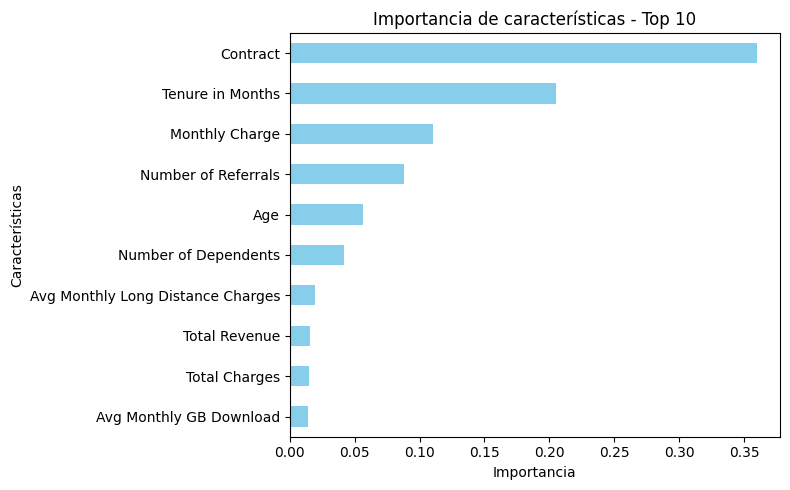

In [ ]:
# ============================================================
# CELDA 12 – Gráfico de importancia (Top 10)
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances_plot = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_plot.tail(10).plot(kind='barh', color='skyblue')
plt.title("Importancia de características - Top 10")
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.tight_layout()
plt.show()


[Impureza] Top 10
 Contract                             0.359763
Tenure in Months                     0.204878
Monthly Charge                       0.110497
Number of Referrals                  0.087964
Age                                  0.056720
Number of Dependents                 0.041923
Avg Monthly Long Distance Charges    0.019588
Total Revenue                        0.015327
Total Charges                        0.014656
Avg Monthly GB Download              0.013849
dtype: float64

[Permutación] Top 10
 Contract                   0.084408
Tenure in Months           0.071813
Number of Referrals        0.041351
Monthly Charge             0.028338
Age                        0.012140
Total Charges              0.008460
Total Revenue              0.007398
Number of Dependents       0.005615
Avg Monthly GB Download    0.003756
Married                    0.003642
dtype: float64


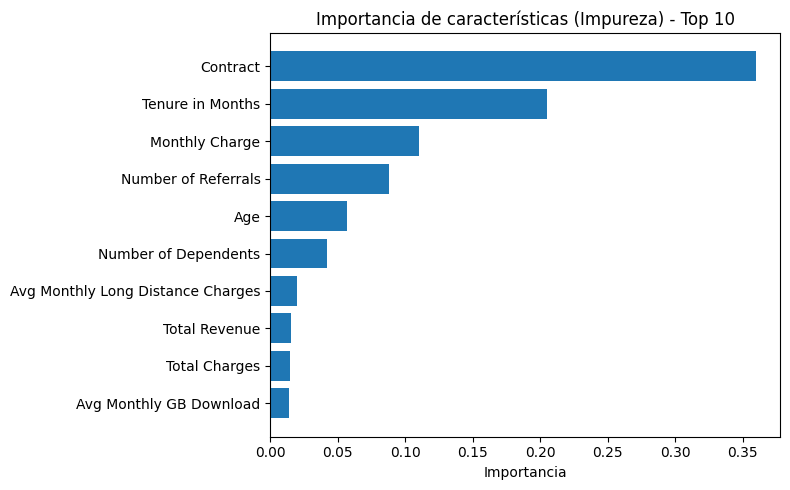

In [ ]:
# ============================================================
# CELDA 13 – Permutation Importance + gráfico doble
# ============================================================
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

feature_names = X.columns.tolist()

# Impureza
impurity_importance = pd.Series(
    best_model.feature_importances_, index=feature_names
).sort_values(ascending=False)
print("\n[Impureza] Top 10\n", impurity_importance.head(10))

# Permutación
pi = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20, random_state=42, n_jobs=-1
)
perm_importance = pd.Series(
    pi.importances_mean, index=feature_names
).sort_values(ascending=False)
print("\n[Permutación] Top 10\n", perm_importance.head(10))

# Gráfico
top = impurity_importance.head(10).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(top.index, top.values)
plt.title("Importancia de características (Impureza) - Top 10")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

AUC: 0.8812


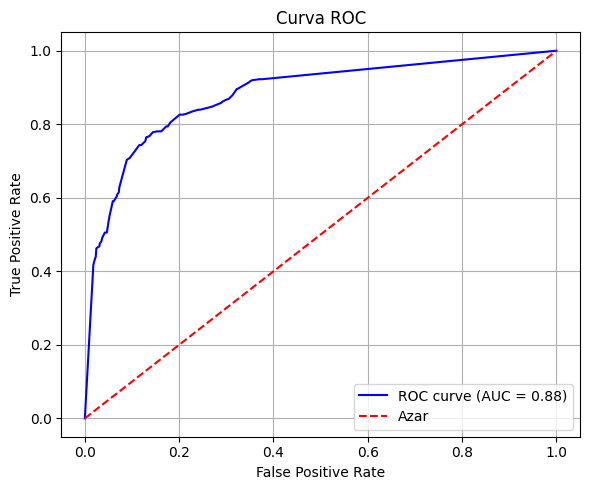

In [ ]:
# ============================================================
# CELDA 14 – Curva ROC y AUC
# ============================================================
from sklearn.metrics import roc_auc_score, roc_curve

y_proba   = best_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()